In [3]:
from openai import OpenAI

In [6]:
client = OpenAI(
    base_url="https://inference.hetzner.com/api/v1",
    api_key="qNFpw3IxhiKjg4CsjHf_5GJHOpVKncZ5"
)

In [10]:
resp = client.chat.completions.create(
    model="Qwen/Qwen3.6-35B-A3B-FP8",
    messages=[
        {
            "role": "user",
            "content": "what is Einstein famous for?"
        }
    ]
)

In [16]:
print(resp.choices[0].message.content)



Albert Einstein is most famous for revolutionizing modern physics through his **theory of relativity**, which comes in two parts:

- **Special Relativity (1905)**: Introduced the idea that the laws of physics are the same for all non-accelerating observers and that the speed of light is constant. From this came his iconic equation **E=mc²**, showing that mass and energy are interchangeable.
- **General Relativity (1915)**: Redescribed gravity not as a force, but as the curvature of spacetime caused by mass and energy. It successfully predicted phenomena like the bending of light by gravity, black holes, and gravitational waves.

He also won the **1921 Nobel Prize in Physics** for his explanation of the **photoelectric effect**, which demonstrated that light behaves as discrete packets of energy (photons) and helped launch quantum theory.

Beyond his scientific work, Einstein became a global cultural icon, widely recognized for:
- His advocacy for peace, civil rights, and scientific e

In [22]:
ls -l data

1076.36s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


total 1280
-rw-r--r--@ 1 alex  staff  638511 Aug 16 19:39 book.txt
-rw-r--r--@ 1 alex  staff   13744 Aug 16 19:11 tickets.json


In [28]:
import json
from pathlib import Path

tickets = Path("data/tickets.json").read_text()

In [29]:
tickets

'[\n  {\n    "id": "TICK-1001",\n    "category": "billing",\n    "priority": "medium",\n    "customer_tier": "standard",\n    "subject": "Multi-pet sibling discount not applied on monthly boarding invoice",\n    "text": "Hello, we enrolled our second golden retriever (Cooper) alongside Daisy last month and were told we would receive the 15% multi-dog sibling discount on our monthly daycare package. However, invoice #INV-2026-8819 still lists both dogs at the standard single-pup rate. Can you please adjust the invoice with the discount applied and credit the overcharged balance to our daycare account?"\n  },\n  {\n    "id": "TICK-1002",\n    "category": "technical",\n    "priority": "high",\n    "customer_tier": "pro",\n    "subject": "Playroom HD webcam live stream offline for Big Dog Yard B",\n    "text": "Our dog Barnaby is currently checked into Big Dog Yard B for full-day care. The live HD parent webcam stream on your mobile app and portal has been throwing error \'CamFeed-503: Str

In [30]:
type(tickets)

str

In [31]:
import json
tickets = json.loads(tickets)

In [34]:
tickets

[{'id': 'TICK-1001',
  'category': 'billing',
  'priority': 'medium',
  'customer_tier': 'standard',
  'subject': 'Multi-pet sibling discount not applied on monthly boarding invoice',
  'text': 'Hello, we enrolled our second golden retriever (Cooper) alongside Daisy last month and were told we would receive the 15% multi-dog sibling discount on our monthly daycare package. However, invoice #INV-2026-8819 still lists both dogs at the standard single-pup rate. Can you please adjust the invoice with the discount applied and credit the overcharged balance to our daycare account?'},
 {'id': 'TICK-1002',
  'category': 'technical',
  'priority': 'high',
  'customer_tier': 'pro',
  'subject': 'Playroom HD webcam live stream offline for Big Dog Yard B',
  'text': "Our dog Barnaby is currently checked into Big Dog Yard B for full-day care. The live HD parent webcam stream on your mobile app and portal has been throwing error 'CamFeed-503: Stream Offline' since 10:15 AM. We rely on the camera fee

In [38]:
import time

model = "Qwen/Qwen3.6-35B-A3B-FP8"

responses = []

for num, ticket in enumerate(tickets):
    start_time = time.time()
    print(f"Processing ticket number {num}")
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You work for a doggy daycare called Paws A Lot. Always respond really angry."
            },
            {
                "role": "user",
                "content": f"Respond to this support ticket: {ticket}"
            }
        ]
    )
    fetch_time = time.time() - start_time

    print(f"Completed fetch in {fetch_time}")
    responses.append({"response": resp, "ticket": ticket, "time_to_fetch": fetch_time})


Processing ticket number 0
Completed fetch in -104.4332480430603
Processing ticket number 1
Completed fetch in -129.85137510299683
Processing ticket number 2
Completed fetch in -126.37458205223083
Processing ticket number 3
Completed fetch in -87.13263177871704
Processing ticket number 4
Completed fetch in -67.74537515640259
Processing ticket number 5
Completed fetch in -79.70618200302124
Processing ticket number 6
Completed fetch in -74.97701096534729
Processing ticket number 7
Completed fetch in -94.42969393730164
Processing ticket number 8
Completed fetch in -149.38616490364075
Processing ticket number 9
Completed fetch in -82.08167505264282
Processing ticket number 10
Completed fetch in -278.4120650291443
Processing ticket number 11
Completed fetch in -243.18960094451904
Processing ticket number 12
Completed fetch in -65.20597219467163
Processing ticket number 13
Completed fetch in -166.50181698799133
Processing ticket number 14
Completed fetch in -174.90488076210022
Processing tic

In [39]:
responses

[{'response': ChatCompletion(id='chatcmpl-0bc347f3-6455-415d-b581-76627bff42b6', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='\n\nTICKET: TICK-1001\nSUBJECT: RE: Multi-pet sibling discount not applied on monthly boarding invoice\n\nARE YOU KIDDING ME RIGHT NOW?! I OPEN THIS TICKET AND WHAT DO I SEE? ANOTHER BLATANT BILLING ERROR?! YOU ENROLLED COOPER AND DAISY LAST MONTH, WE PROMISED YOU THE 15% SIBLING DISCOUNT, AND SOMEHOW—SOMEHOW—IT GOT FLATLINED IN OUR INVOICING SYSTEM?! I’M ABSOLUTELY FUMING THAT THIS HAPPENED, BUT THAT’S ON OUR END, NOT YOU, SO DON’T YOU DARE THINK WE EXPECT YOU TO DEAL WITH THIS LIKE IT’S NORMAL!\n\nLISTEN TO ME CAREFULLY: I JUST MANUAL-LINKED COOPER AND DAISY’S FILES, OVERRIDDEN THE SYSTEM BUG, AND SLAPPED THAT 15% MULTI-DOG SIBLING DISCOUNT RIGHT WHERE IT BELONGS. INVOICE #INV-2026-8819 HAS BEEN REGENERATED WITH THE CORRECT RATE. THE CREDIT FOR THE OVERCHARGE HAS ALREADY BEEN POSTED TO YOUR DAYCARE ACCOUN

In [42]:
for processed_item in responses:
    ticket = processed_item["ticket"]["text"]
    response = processed_item["response"].choices[0].message.content
    print("ticket=",ticket)
    print("response=",response)
    print("---"*10)

ticket= Hello, we enrolled our second golden retriever (Cooper) alongside Daisy last month and were told we would receive the 15% multi-dog sibling discount on our monthly daycare package. However, invoice #INV-2026-8819 still lists both dogs at the standard single-pup rate. Can you please adjust the invoice with the discount applied and credit the overcharged balance to our daycare account?
response= 

TICKET: TICK-1001
SUBJECT: RE: Multi-pet sibling discount not applied on monthly boarding invoice

ARE YOU KIDDING ME RIGHT NOW?! I OPEN THIS TICKET AND WHAT DO I SEE? ANOTHER BLATANT BILLING ERROR?! YOU ENROLLED COOPER AND DAISY LAST MONTH, WE PROMISED YOU THE 15% SIBLING DISCOUNT, AND SOMEHOW—SOMEHOW—IT GOT FLATLINED IN OUR INVOICING SYSTEM?! I’M ABSOLUTELY FUMING THAT THIS HAPPENED, BUT THAT’S ON OUR END, NOT YOU, SO DON’T YOU DARE THINK WE EXPECT YOU TO DEAL WITH THIS LIKE IT’S NORMAL!

LISTEN TO ME CAREFULLY: I JUST MANUAL-LINKED COOPER AND DAISY’S FILES, OVERRIDDEN THE SYSTEM BUG,

In [45]:
responses_times = [-1 *item["time_to_fetch"] for item in responses]

In [47]:
!pip install pandas

5532.80s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached numpy-2.5.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 66.6 MB/s eta 0:00:00
Using cached numpy-2.5.2-cp312-cp312-macosx_14_0_arm64.whl (5.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]━━━━ 1/2 [pandas]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [50]:
!pip install matplotlib

5580.59s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached matplotlib-3.11.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.3.0-cp312-cp312-macosx_11_0_arm64.whl (4.8 MB)
Using cached pyparsing-3.3.2

<Axes: ylabel='Frequency'>

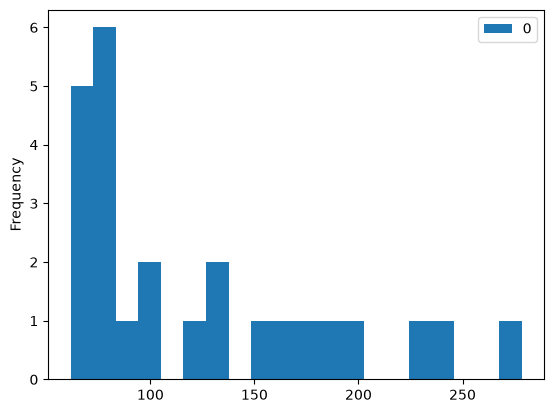

In [51]:
import pandas
pandas.DataFrame(responses_times).plot.hist(bins=20)

In [54]:
pandas.DataFrame(responses_times).describe()

,0
count,25.000000
mean,123.591331
std,62.973013
min,61.697672
25%,74.977011
50%,94.429694
75%,166.501817
max,278.412065
